# Cohort Retention Analysis

## Objective
Group customers by the week they made their first purchase (acquisition cohort) and track how many of them made repeat purchases in subsequent weeks within the same month — to understand short-term retention behavior.

## Data Limitation
This dataset covers only November 2019 (single month). As a result, this analysis measures **within-month, week-over-week retention** rather than long-term (multi-month) customer retention. Findings should be interpreted as early-stage engagement patterns, not full customer lifecycle retention.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/sample_15pct.csv", parse_dates=['event_time'])
purchases = df[df['event_type'] == 'purchase'].copy()
purchases.shape

(137931, 9)

## Assigning Cohorts and Purchase Weeks
Each customer is assigned to a cohort based on the week of their first purchase. We then track which week each subsequent purchase falls into, relative to their cohort week.

In [7]:
purchases['purchase_week'] = purchases['event_time'].dt.isocalendar().week

cohort_week = purchases.groupby('user_id')['purchase_week'].min().reset_index()
cohort_week.columns = ['user_id', 'cohort_week']

purchases = purchases.merge(cohort_week, on='user_id')
purchases['week_number'] = purchases['purchase_week'] - purchases['cohort_week']

purchases[['user_id', 'cohort_week', 'purchase_week', 'week_number']].head(10)

,user_id,cohort_week,purchase_week,week_number
0,566191509,44,44,0
1,547539781,44,44,0
2,559148045,44,44,0
3,546260818,44,44,0
4,550864895,44,44,0
5,520563628,44,44,0
6,526900210,44,44,0
7,517024624,44,44,0
8,564639768,44,44,0
9,512911157,44,44,0


## Building the Retention Matrix
For each cohort (week of first purchase), calculating how many unique customers made a purchase in week 0 (acquisition week), week 1, week 2, and so on.

In [8]:
cohort_data = purchases.groupby(['cohort_week', 'week_number'])['user_id'].nunique().reset_index()
cohort_pivot = cohort_data.pivot(index='cohort_week', columns='week_number', values='user_id')

cohort_size = cohort_pivot.iloc[:, 0]
retention_matrix = cohort_pivot.divide(cohort_size, axis=0) * 100

retention_matrix.round(1)

week_number,0,1,2,3,4
cohort_week,,,,,
44,100.0,10.1,8.0,5.4,4.1
45,100.0,8.2,5.1,3.9,NaN
46,100.0,4.1,2.7,NaN,NaN
47,100.0,5.7,NaN,NaN,NaN
48,100.0,NaN,NaN,NaN,NaN


## Key Insight
Retention drops sharply after Week 0 across all cohorts — only **~10% or fewer** customers return for a repeat purchase within a week of their first purchase. This indicates most customers are one-time or occasional buyers within this observation window, reinforcing the RFM finding (Notebook 5) that a large share of customers fall into "New Customer" or "Lost Customer" segments rather than "Loyal" or "Champion" categories.

**Note:** NaN values indicate cohorts that had not yet reached that many weeks of observation by the end of the dataset (e.g., Cohort 48 — the last week of November — has no Week 1+ data available).

**Business Recommendation:** The steep Week 0 → Week 1 drop-off suggests an opportunity for a "second purchase" incentive (e.g., a time-limited discount code sent within 3–5 days of first purchase) to convert one-time buyers into repeat customers before they disengage entirely.

## Retention Heatmap Visualization

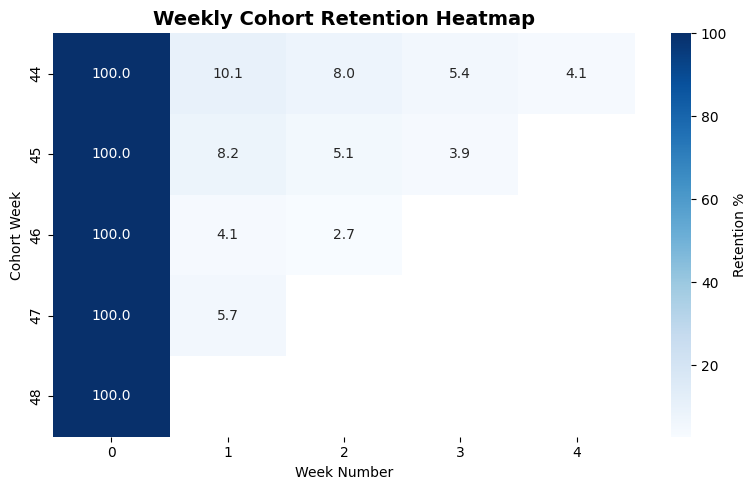

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
sns.heatmap(retention_matrix, annot=True, fmt='.1f', cmap='Blues', cbar_kws={'label': 'Retention %'})
plt.title('Weekly Cohort Retention Heatmap', fontsize=14, fontweight='bold')
plt.xlabel('Week Number')
plt.ylabel('Cohort Week')
plt.tight_layout()
plt.savefig("../Reports/cohort_retention_heatmap.png", dpi=150)
plt.show()

In [10]:
retention_matrix.reset_index().to_csv("../Reports/cohort_retention_matrix.csv", index=False)
print("Notebook 6 exports done")

Notebook 6 exports done
